# Baseline: Árvore de Decisão

> Objetivo: treinar um modelo simples de árvore de decisão e avaliar desempenho no conjunto de teste.

> Referência: conteúdo copiado e adaptado de Modelação.ipynb.

## 1) Importação e leitura dos dados

In [46]:
# importações de bibliotecas
import pandas as pd
import sklearn as sk
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import tree
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

ortho_clean = pd.read_csv('ortho_eda_clean.csv')

## 2) Preparação dos dados

In [47]:
# Converter variáveis categóricas e definir X/y
ortho_clean['Grupo_pre'] = ortho_clean['Grupo_pre'].astype('category')
ortho_clean['Sexo'] = ortho_clean['Sexo'].astype('category')

X = ortho_clean.drop('mudanca_CPAK', axis=1)
y = ortho_clean['mudanca_CPAK']

X_ohe = pd.get_dummies(X, columns=['Grupo_pre', 'Sexo'], drop_first=True)

# Split estratificado dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## 3) Árvore de decisão: baseline

In [48]:
# Treino do baseline com Árvore de Decisão
clf_DT = tree.DecisionTreeClassifier(random_state=42)
clf_DT = clf_DT.fit(X_train, y_train)

# Previsões no conjunto de teste
y_pred_DT = clf_DT.predict(X_test)
y_pred_DT

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# 3.1) Avaliação do modelo

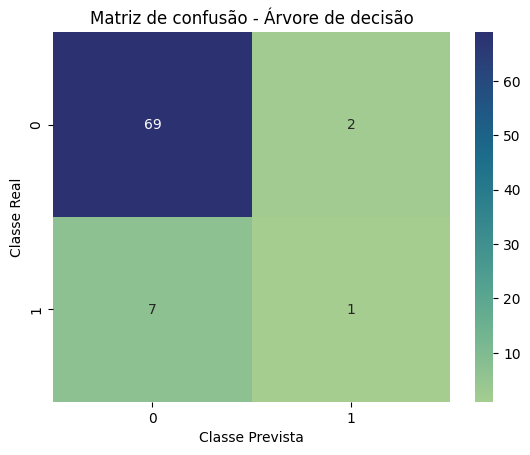

In [49]:
# Matriz de confusão do baseline (Árvore de Decisão)
confusion_m = confusion_matrix(y_test, y_pred_DT)

# Visualização da matriz de confusão
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='crest')
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.title("Matriz de confusão - Árvore de decisão")
plt.show()

In [50]:
# Relatório de classificação do baseline
print(classification_report(y_test, y_pred_DT))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94        71
           1       0.33      0.12      0.18         8

    accuracy                           0.89        79
   macro avg       0.62      0.55      0.56        79
weighted avg       0.85      0.89      0.86        79



In [51]:
# Área sob a curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_DT)
print("AUC:", auc)

AUC: 0.5484154929577465


In [52]:
# Validação cruzada (K-fold) para estimar generalização
pred = cross_val_predict(clf_DT, X, y)

print(classification_report(y, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9227    0.9110    0.9168       236
           1     0.2759    0.3077    0.2909        26

    accuracy                         0.8511       262
   macro avg     0.5993    0.6094    0.6039       262
weighted avg     0.8586    0.8511    0.8547       262



In [53]:
# validação cruzada (k-fold estratificada)
pred_estratificada = cross_val_predict(clf_DT, X, y, cv=sk.model_selection.StratifiedKFold(n_splits=5))
print(classification_report(y, pred_estratificada, digits=4))

              precision    recall  f1-score   support

           0     0.9227    0.9110    0.9168       236
           1     0.2759    0.3077    0.2909        26

    accuracy                         0.8511       262
   macro avg     0.5993    0.6094    0.6039       262
weighted avg     0.8586    0.8511    0.8547       262



## 4) Teste simples de hipoteses:
Nesta secção avaliamos se algumas variáveis estão a representar a mesma informação e se podem ser removidas sem perda relevante de desempenho.

- Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)
- Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

Objetivo: identificar a forma mais simples de representar os dados, reduzindo redundância e mantendo qualidade preditiva.

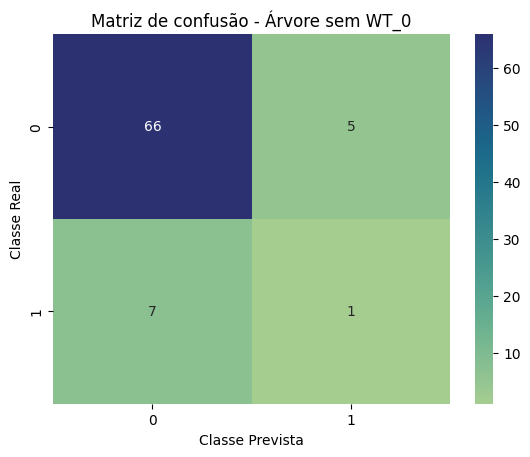

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC sem WT_0: 0.5272887323943662


In [54]:
# Remover WT_0 dos dados de treino e teste
col_wt0 = 'WT_0'

if col_wt0 in X_train.columns and col_wt0 in X_test.columns:
    X_train_sem_wt = X_train.drop(columns=[col_wt0])
    X_test_sem_wt = X_test.drop(columns=[col_wt0])

    # Treinar modelo sem WT_0
    clf_DT_sem_wt = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_sem_wt = clf_DT_sem_wt.fit(X_train_sem_wt, y_train)

    # Previsões
    y_pred_DT_sem_wt = clf_DT_sem_wt.predict(X_test_sem_wt)

    # Matriz de confusão
    confusion_sem_wt = confusion_matrix(y_test, y_pred_DT_sem_wt)
    sns.heatmap(confusion_sem_wt, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore sem WT_0")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_sem_wt))
    auc_sem_wt = roc_auc_score(y_test, y_pred_DT_sem_wt)
    print("AUC sem WT_0:", auc_sem_wt)
else:
    print("WT_0 não foi encontrada em X_train/X_test.")

# 4.1) Comparação 1: WT_0 versus os seus componentes (WR_0, WD_0 e WAtotal_0)

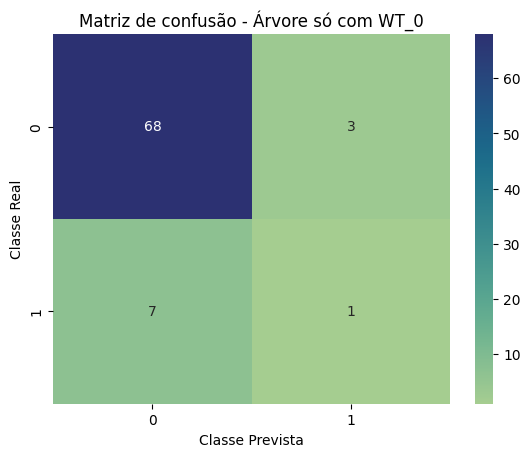

              precision    recall  f1-score   support

           0       0.91      0.96      0.93        71
           1       0.25      0.12      0.17         8

    accuracy                           0.87        79
   macro avg       0.58      0.54      0.55        79
weighted avg       0.84      0.87      0.85        79

AUC só com WT_0: 0.5413732394366197


In [ ]:
# Manter WT_0 e remover os componentes (WD_0, WR_0, WAtotal_0/WATotal)
mapa = {c.lower(): c for c in X_train.columns}

chave_wa = 'watotal_0' if 'watotal_0' in mapa else ('watotal' if 'watotal' in mapa else None)
componentes = []
for chave in ['wd_0', 'wr_0']:
    if chave in mapa:
        componentes.append(mapa[chave])
if chave_wa is not None:
    componentes.append(mapa[chave_wa])

if 'wt_0' in mapa:
    X_train_so_wt = X_train.drop(columns=componentes, errors='ignore')
    X_test_so_wt = X_test.drop(columns=componentes, errors='ignore')

    # Treinar modelo mantendo WT_0
    clf_DT_so_wt = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_wt = clf_DT_so_wt.fit(X_train_so_wt, y_train)

    # Previsões
    y_pred_DT_so_wt = clf_DT_so_wt.predict(X_test_so_wt)

    # Matriz de confusão
    confusion_so_wt = confusion_matrix(y_test, y_pred_DT_so_wt)
    sns.heatmap(confusion_so_wt, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com WT_0")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_wt))
    auc_so_wt = roc_auc_score(y_test, y_pred_DT_so_wt)
    print("AUC só com WT_0:", auc_so_wt)
else:
    print("WT_0 não foi encontrada em X_train/X_test.")

Com base nos resultados obtidos, a comparação entre WT_0 e os seus componentes fica apresentada no mesmo formato do RL_final, permitindo decidir de forma direta qual das duas representações é mais informativa neste contexto.

# 4.2) Comparação 2: IMC versus variáveis de base (Peso e Altura_cm)

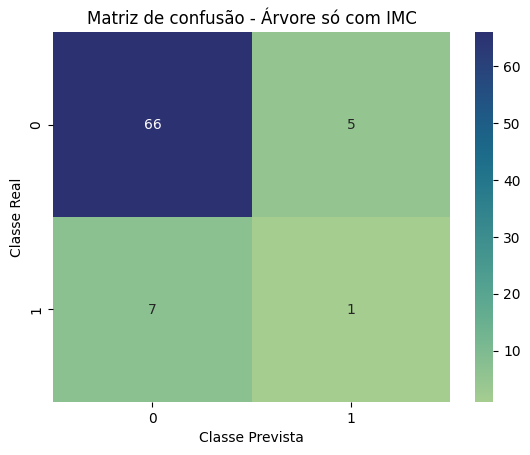

              precision    recall  f1-score   support

           0       0.90      0.93      0.92        71
           1       0.17      0.12      0.14         8

    accuracy                           0.85        79
   macro avg       0.54      0.53      0.53        79
weighted avg       0.83      0.85      0.84        79

AUC só com IMC: 0.5272887323943662


In [55]:
# Manter IMC e remover Peso/Altura_cm
mapa = {c.lower(): c for c in X_train.columns}

col_imc = mapa.get('imc')
col_peso = mapa.get('peso')
col_altura = mapa.get('altura_cm')

if col_imc is not None:
    remover = [c for c in [col_peso, col_altura] if c is not None]
    X_train_so_imc = X_train.drop(columns=remover, errors='ignore')
    X_test_so_imc = X_test.drop(columns=remover, errors='ignore')

    # Treinar modelo mantendo IMC
    clf_DT_so_imc = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_imc = clf_DT_so_imc.fit(X_train_so_imc, y_train)

    # Previsões
    y_pred_DT_so_imc = clf_DT_so_imc.predict(X_test_so_imc)

    # Matriz de confusão
    confusion_so_imc = confusion_matrix(y_test, y_pred_DT_so_imc)
    sns.heatmap(confusion_so_imc, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com IMC")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_imc))
    auc_so_imc = roc_auc_score(y_test, y_pred_DT_so_imc)
    print("AUC só com IMC:", auc_so_imc)
else:
    print("IMC não foi encontrada em X_train/X_test.")

## 8) Teste simples só com Peso e Altura (sem IMC)

Neste bloco removemos IMC dos dados de treino e teste, mantendo Peso e Altura_cm.

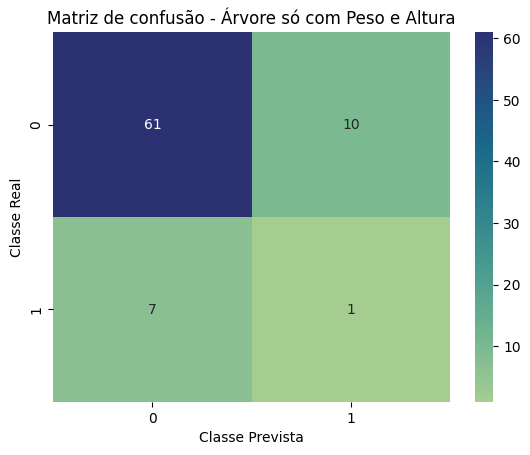

              precision    recall  f1-score   support

           0       0.90      0.86      0.88        71
           1       0.09      0.12      0.11         8

    accuracy                           0.78        79
   macro avg       0.49      0.49      0.49        79
weighted avg       0.82      0.78      0.80        79

AUC só com Peso e Altura: 0.4920774647887324


In [56]:
# Manter Peso/Altura_cm e remover IMC
mapa = {c.lower(): c for c in X_train.columns}

col_imc = mapa.get('imc')
col_peso = mapa.get('peso')
col_altura = mapa.get('altura_cm')

if col_peso is not None and col_altura is not None:
    X_train_so_peso_altura = X_train.drop(columns=[col_imc] if col_imc is not None else [], errors='ignore')
    X_test_so_peso_altura = X_test.drop(columns=[col_imc] if col_imc is not None else [], errors='ignore')

    # Treinar modelo mantendo Peso e Altura
    clf_DT_so_peso_altura = tree.DecisionTreeClassifier(random_state=42)
    clf_DT_so_peso_altura = clf_DT_so_peso_altura.fit(X_train_so_peso_altura, y_train)

    # Previsões
    y_pred_DT_so_peso_altura = clf_DT_so_peso_altura.predict(X_test_so_peso_altura)

    # Matriz de confusão
    confusion_so_peso_altura = confusion_matrix(y_test, y_pred_DT_so_peso_altura)
    sns.heatmap(confusion_so_peso_altura, annot=True, fmt='d', cmap='crest')
    plt.xlabel("Classe Prevista")
    plt.ylabel("Classe Real")
    plt.title("Matriz de confusão - Árvore só com Peso e Altura")
    plt.show()

    # Métricas
    print(classification_report(y_test, y_pred_DT_so_peso_altura))
    auc_so_peso_altura = roc_auc_score(y_test, y_pred_DT_so_peso_altura)
    print("AUC só com Peso e Altura:", auc_so_peso_altura)
else:
    print("Peso/Altura_cm não foram encontradas em X_train/X_test.")

Com base nos resultados obtidos, a comparação entre IMC e as variáveis de base fica apresentada no mesmo formato do RL_final, facilitando a escolha entre a variável composta e a sua representação original.

# 6) Grid Search inicial
Nesta etapa procuramos os melhores hiperparâmetros da Árvore de Decisão sem assumir à partida que um class_weight específico é o melhor cenário.

Melhores parâmetros (Grid inicial): {'class_weight': {0: 1, 1: 1.5}, 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1}
Melhor F1 (CV): 0.2943

Resultado CV (estilo matriz):


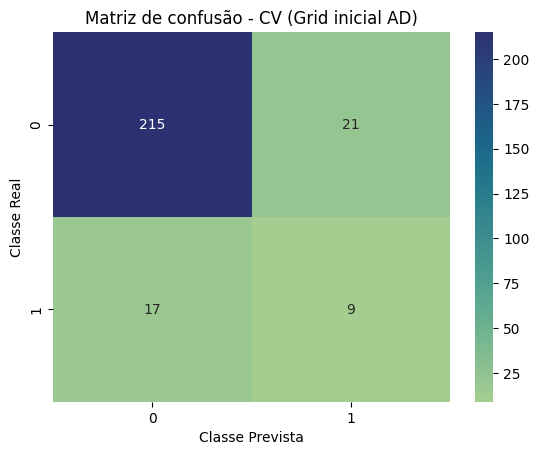

Precision classe 0: 0.9267
Precision classe 1: 0.3000
Recall classe 0: 0.9110
Recall classe 1: 0.3462
F1 classe 0: 0.9188
F1 classe 1: 0.3214
AUC-ROC: 0.6138


In [57]:
# 9.1) Grid Search inicial: criterion, max_depth, min_samples_leaf e class_weight
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV

X_modelagem = X.copy()

# OHE exatamente nas variáveis categóricas (se existirem)
cols_ohe = [c for c in ['Grupo_pre', 'Sexo'] if c in X_modelagem.columns]
X_modelagem = pd.get_dummies(X_modelagem, columns=cols_ohe, drop_first=True)

cv_grid = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_ad = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 8, None],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': [None, 'balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
}

def calcular_metricas_modelo(y_true, y_pred, y_prob):
    precisao, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )
    return {
        'Precision_classe_0': precisao[0],
        'Precision_classe_1': precisao[1],
        'Recall_classe_0': recall[0],
        'Recall_classe_1': recall[1],
        'F1_classe_0': f1[0],
        'F1_classe_1': f1[1],
        'AUC_ROC': roc_auc_score(y_true, y_prob)
    }

def mostrar_resultado_com_matriz(y_true, y_pred, y_prob, titulo):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest')
    plt.xlabel('Classe Prevista')
    plt.ylabel('Classe Real')
    plt.title(titulo)
    plt.show()

    m = calcular_metricas_modelo(y_true, y_pred, y_prob)
    print(f"Precision classe 0: {m['Precision_classe_0']:.4f}")
    print(f"Precision classe 1: {m['Precision_classe_1']:.4f}")
    print(f"Recall classe 0: {m['Recall_classe_0']:.4f}")
    print(f"Recall classe 1: {m['Recall_classe_1']:.4f}")
    print(f"F1 classe 0: {m['F1_classe_0']:.4f}")
    print(f"F1 classe 1: {m['F1_classe_1']:.4f}")
    print(f"AUC-ROC: {m['AUC_ROC']:.4f}")
    return m

modelo_grid = tree.DecisionTreeClassifier(random_state=42)

grid_inicial = GridSearchCV(
    estimator=modelo_grid,
    param_grid=param_grid_ad,
    scoring='f1',
    cv=cv_grid,
    n_jobs=-1
)

grid_inicial.fit(X_modelagem, y)

melhor_modelo_inicial = grid_inicial.best_estimator_
print('Melhores parâmetros (Grid inicial):', grid_inicial.best_params_)
print('Melhor F1 (CV):', round(grid_inicial.best_score_, 4))

pred_cv_inicial = cross_val_predict(
    melhor_modelo_inicial,
    X_modelagem,
    y,
    cv=cv_grid
)
prob_cv_inicial = cross_val_predict(
    melhor_modelo_inicial,
    X_modelagem,
    y,
    cv=cv_grid,
    method='predict_proba'
)[:, 1]

print('\nResultado CV (estilo matriz):')
metricas_cv_inicial = mostrar_resultado_com_matriz(
    y,
    pred_cv_inicial,
    prob_cv_inicial,
    'Matriz de confusão - CV (Grid inicial AD)'
)

# 6.2) Grid Search no conjunto de treino e avaliação holdout

Resultado holdout (estilo matriz):


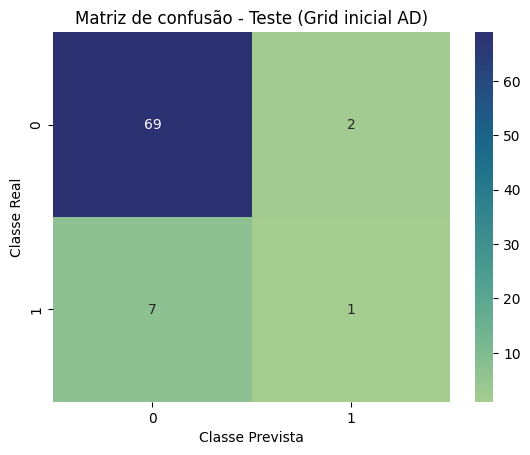

Precision classe 0: 0.9079
Precision classe 1: 0.3333
Recall classe 0: 0.9718
Recall classe 1: 0.1250
F1 classe 0: 0.9388
F1 classe 1: 0.1818
AUC-ROC: 0.5783


In [ ]:
# 6.2) Grid Search no conjunto de treino e avaliação holdout
X_train_grid, X_test_grid, y_train_grid, y_test_grid = train_test_split(
    X_modelagem,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

grid_holdout = GridSearchCV(
    estimator=tree.DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_ad,
    scoring='f1',
    cv=cv_grid,
    n_jobs=-1
)

grid_holdout.fit(X_train_grid, y_train_grid)
melhor_modelo_inicial = grid_holdout.best_estimator_

print('Melhores parâmetros no treino (Grid Search):', grid_holdout.best_params_)
print('Melhor F1 no treino (CV):', round(grid_holdout.best_score_, 4))

y_pred_grid_teste = melhor_modelo_inicial.predict(X_test_grid)
y_prob_grid_teste = melhor_modelo_inicial.predict_proba(X_test_grid)[:, 1]

print('Resultado holdout (estilo matriz):')
metricas_holdout_inicial = mostrar_resultado_com_matriz(
    y_test_grid,
    y_pred_grid_teste,
    y_prob_grid_teste,
    'Matriz de confusão - Teste (Grid Search no treino AD)'
)

# 8) Afinação de threshold para reduzir falsos positivos
Com o melhor modelo encontrado no Grid inicial, ajustamos o limiar de decisão para controlar melhor o compromisso entre precision e recall.

In [59]:
# 8.1) Sweep de threshold
melhor_modelo_inicial.fit(X_train_grid, y_train_grid)
y_prob_thr = melhor_modelo_inicial.predict_proba(X_test_grid)[:, 1]

thresholds = [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]
linhas_thr = []

for thr in thresholds:
    y_pred_thr_tmp = (y_prob_thr >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_grid, y_pred_thr_tmp).ravel()
    metricas_thr = calcular_metricas_modelo(y_test_grid, y_pred_thr_tmp, y_prob_thr)

    linhas_thr.append({
        'threshold': thr,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp),
        'Precision_classe_0': metricas_thr['Precision_classe_0'],
        'Precision_classe_1': metricas_thr['Precision_classe_1'],
        'Recall_classe_0': metricas_thr['Recall_classe_0'],
        'Recall_classe_1': metricas_thr['Recall_classe_1'],
        'F1_classe_0': metricas_thr['F1_classe_0'],
        'F1_classe_1': metricas_thr['F1_classe_1'],
        'AUC_ROC': metricas_thr['AUC_ROC']
    })

resumo_threshold = pd.DataFrame(linhas_thr)
print('=== Tabela de threshold tuning (métricas por classe + AUC-ROC) ===')
print(resumo_threshold.round(4))

linha_base = resumo_threshold[resumo_threshold['threshold'] == 0.50].iloc[0]
precision_1_base = float(linha_base['Precision_classe_1'])

candidatos = resumo_threshold[
    resumo_threshold['Precision_classe_1'] >= precision_1_base
] .copy()

if len(candidatos) == 0:
    melhor_thr = 0.50
else:
    candidatos = candidatos.sort_values(
        by=['FP', 'F1_classe_1', 'Recall_classe_1'],
        ascending=[True, False, False]
    )
    melhor_thr = float(candidatos.iloc[0]['threshold'])

print(f'\nThreshold recomendado: {melhor_thr:.2f}')

y_pred_recomendado = (y_prob_thr >= melhor_thr).astype(int)
cm_thr = confusion_matrix(y_test_grid, y_pred_recomendado)

linha_recomendada = resumo_threshold[resumo_threshold['threshold'] == melhor_thr].iloc[0]
comparacao_threshold = pd.DataFrame([
    {
        'Cenario': 'Threshold 0.50 (baseline)',
        'Threshold': 0.50,
        'FP': int(linha_base['FP']),
        'Precision_classe_0': float(linha_base['Precision_classe_0']),
        'Precision_classe_1': float(linha_base['Precision_classe_1']),
        'Recall_classe_0': float(linha_base['Recall_classe_0']),
        'Recall_classe_1': float(linha_base['Recall_classe_1']),
        'F1_classe_0': float(linha_base['F1_classe_0']),
        'F1_classe_1': float(linha_base['F1_classe_1']),
        'AUC_ROC': float(linha_base['AUC_ROC'])
    },
    {
        'Cenario': 'Threshold recomendado',
        'Threshold': melhor_thr,
        'FP': int(linha_recomendada['FP']),
        'Precision_classe_0': float(linha_recomendada['Precision_classe_0']),
        'Precision_classe_1': float(linha_recomendada['Precision_classe_1']),
        'Recall_classe_0': float(linha_recomendada['Recall_classe_0']),
        'Recall_classe_1': float(linha_recomendada['Recall_classe_1']),
        'F1_classe_0': float(linha_recomendada['F1_classe_0']),
        'F1_classe_1': float(linha_recomendada['F1_classe_1']),
        'AUC_ROC': float(linha_recomendada['AUC_ROC'])
    }
])

=== Tabela de threshold tuning (métricas por classe + AUC-ROC) ===
   threshold  TN  FP  FN  TP  Precision_classe_0  Precision_classe_1  \
0       0.40  68   3   7   1              0.9067              0.2500   
1       0.45  68   3   7   1              0.9067              0.2500   
2       0.50  69   2   7   1              0.9079              0.3333   
3       0.55  69   2   7   1              0.9079              0.3333   
4       0.60  69   2   7   1              0.9079              0.3333   
5       0.65  69   2   7   1              0.9079              0.3333   
6       0.70  69   2   7   1              0.9079              0.3333   

   Recall_classe_0  Recall_classe_1  F1_classe_0  F1_classe_1  AUC_ROC  
0           0.9577            0.125       0.9315       0.1667   0.5783  
1           0.9577            0.125       0.9315       0.1667   0.5783  
2           0.9718            0.125       0.9388       0.1818   0.5783  
3           0.9718            0.125       0.9388       0.1818   

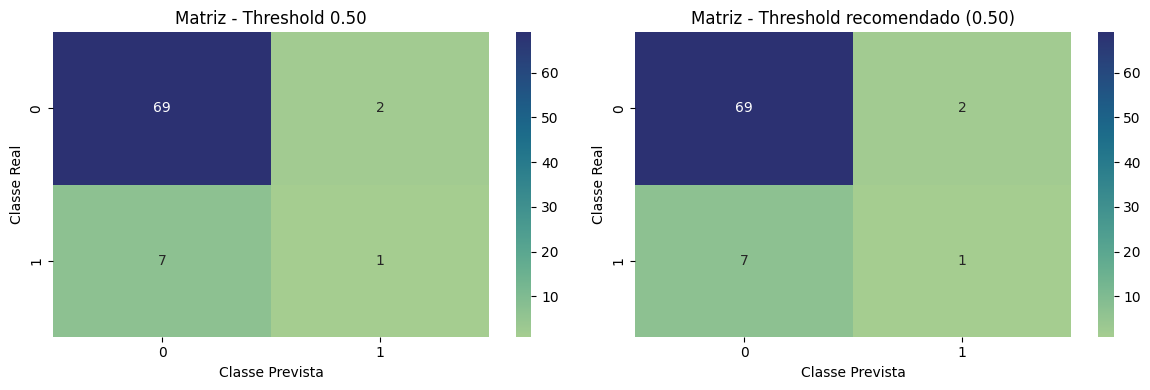

=== Threshold 0.50 ===
Precision classe 0: 0.9079
Precision classe 1: 0.3333
Recall classe 0: 0.9718
Recall classe 1: 0.1250
F1 classe 0: 0.9388
F1 classe 1: 0.1818
AUC-ROC: 0.5783

=== Threshold recomendado ===
Precision classe 0: 0.9079
Precision classe 1: 0.3333
Recall classe 0: 0.9718
Recall classe 1: 0.1250
F1 classe 0: 0.9388
F1 classe 1: 0.1818
AUC-ROC: 0.5783


In [60]:
# 8.2) Avaliação final do threshold recomendado (estilo matriz)
y_pred_base = (y_prob_thr >= 0.50).astype(int)
cm_base = confusion_matrix(y_test_grid, y_pred_base)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz - Threshold 0.50')

plt.subplot(1, 2, 2)
sns.heatmap(cm_thr, annot=True, fmt='d', cmap='crest')
plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title(f'Matriz - Threshold recomendado ({melhor_thr:.2f})')
plt.tight_layout()
plt.show()

metricas_base = calcular_metricas_modelo(y_test_grid, y_pred_base, y_prob_thr)
metricas_recomendado = calcular_metricas_modelo(y_test_grid, y_pred_recomendado, y_prob_thr)

print('=== Threshold 0.50 ===')
print(f"Precision classe 0: {metricas_base['Precision_classe_0']:.4f}")
print(f"Precision classe 1: {metricas_base['Precision_classe_1']:.4f}")
print(f"Recall classe 0: {metricas_base['Recall_classe_0']:.4f}")
print(f"Recall classe 1: {metricas_base['Recall_classe_1']:.4f}")
print(f"F1 classe 0: {metricas_base['F1_classe_0']:.4f}")
print(f"F1 classe 1: {metricas_base['F1_classe_1']:.4f}")
print(f"AUC-ROC: {metricas_base['AUC_ROC']:.4f}")

print('\n=== Threshold recomendado ===')
print(f"Precision classe 0: {metricas_recomendado['Precision_classe_0']:.4f}")
print(f"Precision classe 1: {metricas_recomendado['Precision_classe_1']:.4f}")
print(f"Recall classe 0: {metricas_recomendado['Recall_classe_0']:.4f}")
print(f"Recall classe 1: {metricas_recomendado['Recall_classe_1']:.4f}")
print(f"F1 classe 0: {metricas_recomendado['F1_classe_0']:.4f}")
print(f"F1 classe 1: {metricas_recomendado['F1_classe_1']:.4f}")
print(f"AUC-ROC: {metricas_recomendado['AUC_ROC']:.4f}")

# 9) Afinação adicional de class_weight
Depois de avaliar o threshold, fazemos uma afinação final de `class_weight` na arquitetura escolhida para a Árvore de Decisão.

In [61]:
# 9.1) Grid final de class_weight na arquitetura escolhida
params_base = grid_inicial.best_params_.copy()

modelo_cw_base = tree.DecisionTreeClassifier(
    random_state=42,
    criterion=params_base['criterion'],
    max_depth=params_base['max_depth'],
    min_samples_leaf=params_base['min_samples_leaf']
 )

param_grid_cw = {
    'class_weight': [
        None,
        'balanced',
        {0: 1, 1: 1.25},
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3}
    ]
}

cv_cw = sk.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_cw = GridSearchCV(
    estimator=modelo_cw_base,
    param_grid=param_grid_cw,
    scoring='f1',
    cv=cv_cw,
    n_jobs=-1
)

grid_cw.fit(X_train_grid, y_train_grid)
melhor_modelo_cw = grid_cw.best_estimator_

print('Melhor class_weight (grid final):', grid_cw.best_params_['class_weight'])
print('Melhor F1 (CV):', round(grid_cw.best_score_, 4))

pred_cv_cw = cross_val_predict(melhor_modelo_cw, X_modelagem, y, cv=cv_cw)
prob_cv_cw = cross_val_predict(melhor_modelo_cw, X_modelagem, y, cv=cv_cw, method='predict_proba')[:, 1]

metricas_cv_cw = calcular_metricas_modelo(y, pred_cv_cw, prob_cv_cw)
resumo_cv_cw = pd.DataFrame([
    {
        'Cenario': 'Melhor class_weight final (CV)',
        'Precision_classe_0_cv': metricas_cv_cw['Precision_classe_0'],
        'Precision_classe_1_cv': metricas_cv_cw['Precision_classe_1'],
        'Recall_classe_0_cv': metricas_cv_cw['Recall_classe_0'],
        'Recall_classe_1_cv': metricas_cv_cw['Recall_classe_1'],
        'F1_classe_0_cv': metricas_cv_cw['F1_classe_0'],
        'F1_classe_1_cv': metricas_cv_cw['F1_classe_1'],
        'AUC_ROC_cv': metricas_cv_cw['AUC_ROC']
    }
])

print('\nResumo CV - melhor class_weight final (métricas por classe + AUC-ROC):')
print(resumo_cv_cw.round(4))

Melhor class_weight (grid final): {0: 1, 1: 1.25}
Melhor F1 (CV): 0.3744

Resumo CV - melhor class_weight final (métricas por classe + AUC-ROC):
                          Cenario  Precision_classe_0_cv  \
0  Melhor class_weight final (CV)                 0.9247   

   Precision_classe_1_cv  Recall_classe_0_cv  Recall_classe_1_cv  \
0                 0.3478              0.9364              0.3077   

   F1_classe_0_cv  F1_classe_1_cv  AUC_ROC_cv  
0          0.9305          0.3265      0.6138  


# 10) Comparação final no teste: matriz + gráficos + métricas
Resumo final com tabela `TN/FP/FN/TP`, representação gráfica das matrizes de confusão e métricas por classe no mesmo formato das secções anteriores.

Resultado holdout final (estilo matriz):


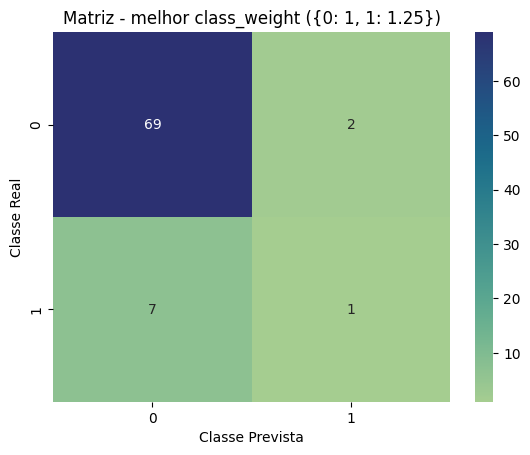

Precision classe 0: 0.9079
Precision classe 1: 0.3333
Recall classe 0: 0.9718
Recall classe 1: 0.1250
F1 classe 0: 0.9388
F1 classe 1: 0.1818
AUC-ROC: 0.5783

Resumo final do modelo escolhido:
Criterion: gini
Max_depth: 3
Min_samples_leaf: 1
Class_weight: {0: 1, 1: 1.25}
Threshold recomendado: 0.5


In [62]:
# 9.2) Avaliação holdout do melhor class_weight final
melhor_modelo_cw.fit(X_train_grid, y_train_grid)
y_pred_cw = melhor_modelo_cw.predict(X_test_grid)
y_prob_cw = melhor_modelo_cw.predict_proba(X_test_grid)[:, 1]

print('Resultado holdout final (estilo matriz):')
metricas_holdout_cw = mostrar_resultado_com_matriz(
    y_test_grid,
    y_pred_cw,
    y_prob_cw,
    f"Matriz - melhor class_weight ({grid_cw.best_params_['class_weight']})"
 )

print('\nResumo final do modelo escolhido:')
print('Criterion:', grid_inicial.best_params_['criterion'])
print('Max_depth:', grid_inicial.best_params_['max_depth'])
print('Min_samples_leaf:', grid_inicial.best_params_['min_samples_leaf'])
print('Class_weight:', grid_cw.best_params_['class_weight'])
print('Threshold recomendado:', round(melhor_thr, 2))

In [ ]:
# 10.1) Comparação gráfica e métricas finais no teste
def linha_matriz_teste(cenario, y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'Cenario': cenario,
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn),
        'TP': int(tp)
    }

cenarios_teste = [
    ('Grid inicial', y_test_grid, y_pred_grid_teste, y_prob_grid_teste),
    (f'Threshold recomendado ({melhor_thr:.2f})', y_test_grid, y_pred_recomendado, y_prob_thr),
    (f'Melhor class_weight ({grid_cw.best_params_["class_weight"]})', y_test_grid, y_pred_cw, y_prob_cw)
]

comparacao_matriz_teste = pd.DataFrame([
    linha_matriz_teste(nome, y_true, y_pred)
    for nome, y_true, y_pred, _ in cenarios_teste
])

print('=== Comparação simples de matrizes de confusão (teste) ===')
print(comparacao_matriz_teste)

print('\n=== Matrizes de confusão (gráfico) ===')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

comparacao_metricas_teste = []
for i, (nome, y_true, y_pred, y_prob) in enumerate(cenarios_teste):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='crest', ax=axes[i], cbar=False)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Classe Prevista')
    axes[i].set_ylabel('Classe Real')

    metricas_tmp = calcular_metricas_modelo(y_true, y_pred, y_prob)
    comparacao_metricas_teste.append({
        'Cenario': nome,
        'Precision_classe_0': metricas_tmp['Precision_classe_0'],
        'Precision_classe_1': metricas_tmp['Precision_classe_1'],
        'Recall_classe_0': metricas_tmp['Recall_classe_0'],
        'Recall_classe_1': metricas_tmp['Recall_classe_1'],
        'F1_classe_0': metricas_tmp['F1_classe_0'],
        'F1_classe_1': metricas_tmp['F1_classe_1'],
        'AUC_ROC': metricas_tmp['AUC_ROC']
    })

plt.tight_layout()
plt.show()

comparacao_metricas_teste = pd.DataFrame(comparacao_metricas_teste)
print('\n=== Métricas por cenário (mesmo formato do documento) ===')
print(comparacao_metricas_teste.round(4))

for _, linha in comparacao_metricas_teste.iterrows():
    print(f"\n=== {linha['Cenario']} ===")
    print(f"Precision classe 0: {linha['Precision_classe_0']:.4f}")
    print(f"Precision classe 1: {linha['Precision_classe_1']:.4f}")
    print(f"Recall classe 0: {linha['Recall_classe_0']:.4f}")
    print(f"Recall classe 1: {linha['Recall_classe_1']:.4f}")
    print(f"F1 classe 0: {linha['F1_classe_0']:.4f}")
    print(f"F1 classe 1: {linha['F1_classe_1']:.4f}")
    print(f"AUC-ROC: {linha['AUC_ROC']:.4f}")